In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
data=pd.read_csv('medical_insurance.csv')
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [61]:
data.smoker.unique()

array(['yes', 'no'], dtype=object)

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [63]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [64]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [65]:

# data['sex']=LabelEncoder().fit_transform(data['sex'])
# data['region']=LabelEncoder().fit_transform(data['region'])
# data['smoker']=LabelEncoder().fit_transform(data['smoker'])


import pickle

le_sex = LabelEncoder()
le_region = LabelEncoder()
le_smoker = LabelEncoder()

data['sex'] = le_sex.fit_transform(data['sex'])
data['region'] = le_region.fit_transform(data['region'])
data['smoker'] = le_smoker.fit_transform(data['smoker'])

# save encoders
pickle.dump(le_sex, open("le_sex.pkl", "wb"))
pickle.dump(le_region, open("le_region.pkl", "wb"))
pickle.dump(le_smoker, open("le_smoker.pkl", "wb"))


In [66]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [67]:
data.shape

(1338, 7)

<Axes: >

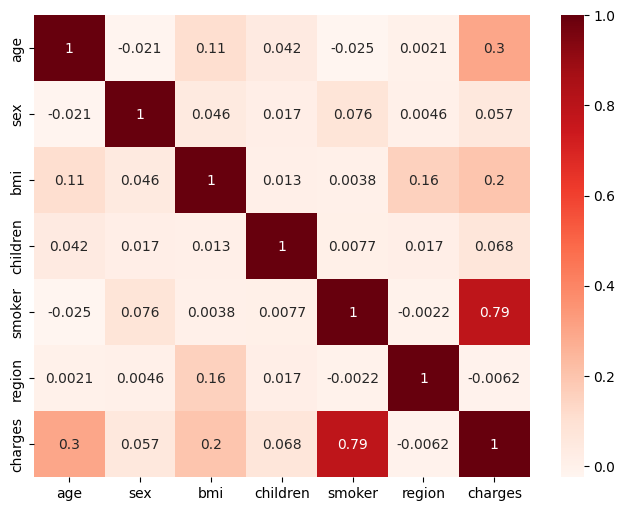

In [68]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='Reds')

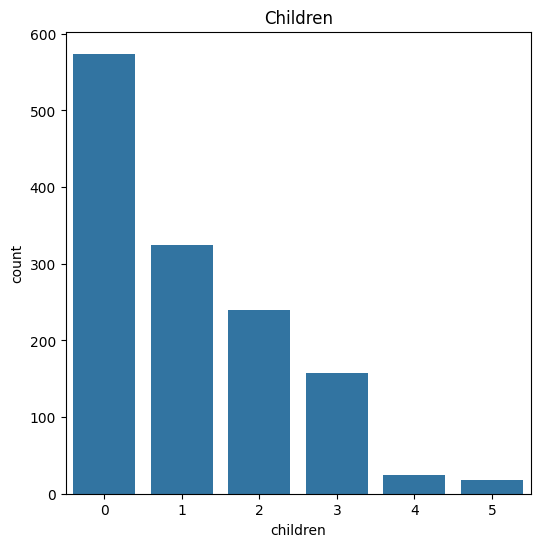

In [69]:
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=data)
plt.title('Children')
plt.show()

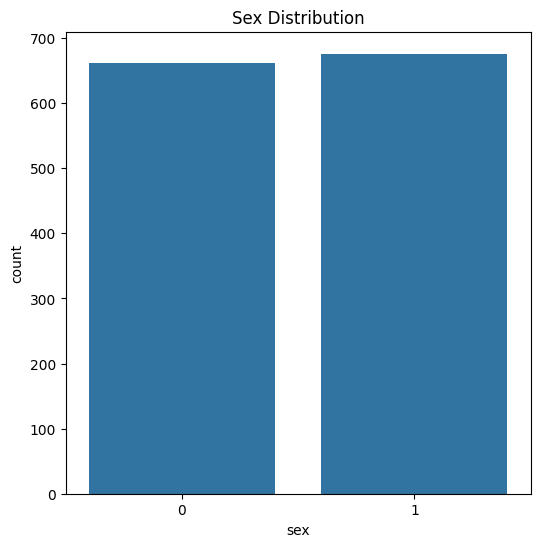

In [70]:
plt.figure(figsize=(6,6))
sns.countplot(x='sex', data=data)
plt.title('Sex Distribution')
plt.show()

In [71]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [72]:
x=data.drop('charges', axis=1)
y=data['charges']

In [73]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [74]:
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((1070, 6), (268, 6), (1070,), (268,))

In [75]:
from sklearn.metrics import r2_score, mean_squared_error 
import numpy as np 
def evaluate_model(model, xtrain, ytrain, xtest, ytest): 
    model.fit(xtrain, ytrain) 
    train_score = model.score(xtrain, ytrain) 
    y_pred = model.predict(xtest) 
    test_r2 = r2_score(ytest, y_pred) 
    rmse = np.sqrt(mean_squared_error(ytest, y_pred)) 
    return train_score, test_r2, rmse

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

models = [
    RandomForestRegressor(),
    DecisionTreeRegressor(),
    LinearRegression()
]

for m in models:
    train_score, test_r2, rmse = evaluate_model(m, xtrain, ytrain, xtest, ytest)
    print(f"{m.__class__.__name__}")
    print("Train R2:", train_score)
    print("Test R2 :", test_r2)
    print("RMSE    :", rmse)
    print("-" * 30)

RandomForestRegressor
Train R2: 0.9761076620799797
Test R2 : 0.8620071826731761
RMSE    : 4628.521345415341
------------------------------
DecisionTreeRegressor
Train R2: 0.9983078124756305
Test R2 : 0.7126850827907278
RMSE    : 6678.718173078081
------------------------------
LinearRegression
Train R2: 0.7417049283233981
Test R2 : 0.7833463107364539
RMSE    : 5799.587091438356
------------------------------


In [77]:
model = DecisionTreeRegressor()
model.fit(xtrain, ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [78]:
import pickle
model_stored=pickle.dump(model, open('model.pkl', 'wb'))
model_stored


In [79]:
with open('model.pkl', 'rb') as f:
    model_stored = pickle.load(f)
model_stored.predict([[19, 0, 27.9, 0, 1, 0]])

c:\Users\amrit\Desktop\Medical_Insurace_ML_FastAPI\medical_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([16884.924])

In [80]:
import pickle

le_sex = pickle.load(open("le_sex.pkl", "rb"))
le_region = pickle.load(open("le_region.pkl", "rb"))
le_smoker = pickle.load(open("le_smoker.pkl", "rb"))

# input
sex = le_sex.transform(['female'])[0]
region = le_region.transform(['southwest'])[0]
smoker = le_smoker.transform(['no'])[0]

input_data = [[19, sex, 27.9, 0, smoker, region]]

prediction = model_stored.predict(input_data)
print(prediction)
# model_stored.predict([[19, 'female', 27.9, 0, 1, 0]])


[1737.376]


c:\Users\amrit\Desktop\Medical_Insurace_ML_FastAPI\medical_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
